# Sinusoid Bayesian-Torch — 5-Seed Evaluation

Same variants as `sinusoidal_bayesian.ipynb` but run over 5 random seeds. Checkpoints use `sinusoid_bayesian_5seed/` and figures use the `5seed_sinusoid_` prefix.

In [1]:
from pathlib import Path
import sys, os, time, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.stats import norm as _norm
from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "shared").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from shared import (checkpoint_exists, load_checkpoint, save_checkpoint,
                    seed_everything, regression_metrics)
from shared.helper.dataloaders import get_sinusoid_example

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEEDS = [711, 42, 123, 456, 789]
sigma_noise = 0.3
num_mc_samples = 100
TRAIN_LO, TRAIN_HI = 0.0, 8.0

FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# Separate checkpoint dir — no collision with single-seed sinusoid_bayesian/sinusoid_{vname}_seed711.pt
CHECKPOINT_BASE = str(ROOT / "results" / "checkpoints" / "sinusoid_bayesian_5seed")
os.makedirs(CHECKPOINT_BASE, exist_ok=True)

plt.rcParams.update({"font.family": "serif", "font.size": 12,
                     "savefig.dpi": 150, "savefig.bbox": "tight"})
print(f"5-seed BNN regression | {len(SEEDS)} seeds | checkpoints -> {CHECKPOINT_BASE}")


Device: cuda
5-seed BNN regression | 5 seeds | checkpoints -> /u/halle/carg/home_at/Documents/BNNs/results/checkpoints/sinusoid_bayesian_5seed


In [2]:
x_grid = torch.linspace(-5, 13, 500).numpy()

def get_map_model(seed):
    seed_everything(seed)
    return torch.nn.Sequential(
        torch.nn.Linear(1, 50), torch.nn.Tanh(), torch.nn.Linear(50, 1))

def build_bnn(model_type, moped, map_weights=None):
    net = torch.nn.Sequential(
        torch.nn.Linear(1, 50), torch.nn.Tanh(), torch.nn.Linear(50, 1))
    if moped and map_weights is not None:
        net.load_state_dict(map_weights)
    dnn_to_bnn(net, {
        "prior_mu": 0.0, "prior_sigma": 1.0,
        "posterior_mu_init": 0.0, "posterior_rho_init": -3.0,
        "type": model_type, "moped_enable": moped, "moped_delta": 0.5,
    })
    return net

def bnn_predict(net, X, n_samples=num_mc_samples):
    net.eval()
    with torch.no_grad():
        preds = torch.stack([net(X) for _ in range(n_samples)])
    return preds.mean(0).squeeze().cpu().numpy(), preds.std(0).squeeze().cpu().numpy()

variant_specs = []
for model_type, short in [("Flipout", "flipout"), ("Reparameterization", "bbb")]:
    for moped in [False, True]:
        init = "moped" if moped else "scratch"
        variant_specs.append({
            "variant_name": f"{short}_{init}",
            "model_type": model_type,
            "moped": moped,
            "epochs": 400 if moped else 1000,
            "plot_title": f"{short.upper().replace('BBB','BBB') if short=='bbb' else short.capitalize()} / {init}",
        })
# Fix display names
for s in variant_specs:
    s["plot_title"] = s["variant_name"].replace("_", " / ").replace("flipout", "Flipout").replace("bbb", "BBB")

print(f"Configured {len(variant_specs)} BNN variants x {len(SEEDS)} seeds = "
      f"{len(variant_specs)*len(SEEDS)} total fits")
print("Variants:", [s["variant_name"] for s in variant_specs])


Configured 4 BNN variants x 5 seeds = 20 total fits
Variants: ['flipout_scratch', 'flipout_moped', 'bbb_scratch', 'bbb_moped']


In [3]:
all_seed_metrics = {}
all_seed_preds   = {}
all_seed_nets    = {}   # {seed: {vname: trained net}}

criterion = nn.MSELoss()

for seed in SEEDS:
    print(f"\n{'='*55}\nSEED {seed}  ({SEEDS.index(seed)+1}/{len(SEEDS)})\n{'='*55}")

    # ----- data -----
    seed_everything(seed)
    X_train, y_train, train_loader, _ = get_sinusoid_example(
        n_data=150, sigma_noise=sigma_noise, batch_size=150)
    X_train_np = X_train.flatten().numpy()
    y_train_np = y_train.flatten().numpy()
    seed_everything(seed + 1)
    X_val = (torch.rand(50) * 8).unsqueeze(-1)
    y_val = torch.sin(X_val) + sigma_noise * torch.randn_like(X_val)
    y_val_np = y_val.flatten().numpy()
    seed_everything(seed + 2)
    X_test_id  = (torch.rand(100) * 8).unsqueeze(-1)
    X_test_ood = torch.cat([torch.rand(60)*5-5, torch.rand(60)*5+8]).unsqueeze(-1)
    y_test_id  = torch.sin(X_test_id)  + sigma_noise * torch.randn_like(X_test_id)
    y_test_ood = torch.sin(X_test_ood) + sigma_noise * torch.randn_like(X_test_ood)
    y_test_id_np = y_test_id.flatten().numpy()

    X_test_grid = torch.linspace(-5, 13, 500).unsqueeze(-1)

    # ----- MAP -----
    map_ckpt = os.path.join(CHECKPOINT_BASE, f"sinusoid_map_seed{seed}.pt")
    map_model = get_map_model(seed)
    if checkpoint_exists(map_ckpt):
        map_model.load_state_dict(
            load_checkpoint(map_ckpt, map_location="cpu")["model_state_dict"])
        print("  MAP: loaded checkpoint")
    else:
        opt = optim.Adam(map_model.parameters(), lr=1e-2)
        t0 = time.time()
        for _ in range(1000):
            for xb, yb in train_loader:
                opt.zero_grad(); loss = criterion(map_model(xb), yb); loss.backward(); opt.step()
        save_checkpoint({"model_state_dict": map_model.state_dict(),
                         "fit_time": time.time()-t0}, map_ckpt)
        print(f"  MAP: trained ({time.time()-t0:.1f}s)")
    map_model.eval()
    map_weights = copy.deepcopy(map_model.state_dict())

    seed_metrics, seed_preds = {}, {}
    for spec in variant_specs:
        vname = spec["variant_name"]
        ckpt = os.path.join(CHECKPOINT_BASE, f"sinusoid_{vname}_seed{seed}.pt")
        net = build_bnn(spec["model_type"], spec["moped"],
                        map_weights=map_weights if spec["moped"] else None)

        if checkpoint_exists(ckpt):
            payload = load_checkpoint(ckpt, map_location="cpu")
            if isinstance(payload, dict) and "model_state_dict" in payload:
                net.load_state_dict(payload["model_state_dict"])
                metrics = dict(payload.get("metrics", {}))
                print(f"  {vname}: loaded")
        else:
            opt = optim.Adam(net.parameters(), lr=1e-3)
            num_samp = len(X_train)
            patience = 75; best_val, best_state, wait, ran = float("inf"), None, 0, 0
            t0 = time.time()
            for epoch in range(spec["epochs"]):
                net.train()
                for xb, yb in train_loader:
                    opt.zero_grad()
                    loss = criterion(net(xb), yb) + get_kl_loss(net) / num_samp
                    loss.backward(); opt.step()
                ran = epoch + 1
                f_mu_val, _ = bnn_predict(net, X_val, n_samples=20)
                val_mse = float(np.mean((f_mu_val - y_val_np)**2))
                if val_mse < best_val - 1e-5:
                    best_val, best_state, wait = val_mse, copy.deepcopy(net.state_dict()), 0
                else:
                    wait += 1
                    if wait >= patience: break
            if best_state is not None:
                net.load_state_dict(best_state)
            fit_time = time.time()-t0
            metrics = {
                "Model_Type": spec["model_type"],
                "Init": "MOPED" if spec["moped"] else "scratch",
                "Epochs": ran, "Best_Val_MSE": best_val, "Fit_Time (s)": fit_time,
            }
            save_checkpoint({"model_state_dict": net.state_dict(), "metrics": metrics}, ckpt)
            print(f"  {vname}: trained ({fit_time:.1f}s, {ran} epochs)")

        f_mu_grid, epi_grid = bnn_predict(net, X_test_grid)
        t_inf = time.time()
        mu_id, epi_id = bnn_predict(net, X_test_id)
        metrics["Inf_Time (s)"] = time.time() - t_inf
        total_id = np.sqrt(epi_id**2 + sigma_noise**2)
        metrics.update(regression_metrics(y_test_id_np, mu_id, total_id))

        seed_metrics[vname] = metrics
        seed_preds[vname] = (f_mu_grid, epi_grid)
        all_seed_nets.setdefault(seed, {})[vname] = net
        print(f"    RMSE={metrics.get('RMSE',float('nan')):.4f}  "
              f"NLL={metrics.get('NLL',float('nan')):.4f}  "
              f"Cal={metrics.get('Calibration_MAE',float('nan')):.4f}")

    all_seed_metrics[seed] = seed_metrics
    all_seed_preds[seed] = seed_preds

print(f"\nCompleted {len(SEEDS)} seeds x {len(variant_specs)} variants.")


SEED 711  (1/5)
  MAP: loaded checkpoint
  flipout_scratch: loaded
    RMSE=0.5945  NLL=1.2793  Cal=0.2480
  flipout_moped: loaded
    RMSE=0.5473  NLL=1.5765  Cal=0.3260
  bbb_scratch: loaded
    RMSE=0.5844  NLL=1.2157  Cal=0.2495
  bbb_moped: loaded
    RMSE=0.5953  NLL=1.6111  Cal=0.3050

SEED 42  (2/5)
  MAP: loaded checkpoint
  flipout_scratch: loaded
    RMSE=0.4982  NLL=0.8510  Cal=0.1520
  flipout_moped: loaded
    RMSE=0.5867  NLL=1.3168  Cal=0.2385
  bbb_scratch: loaded
    RMSE=0.6914  NLL=1.7816  Cal=0.2705
  bbb_moped: loaded
    RMSE=0.5944  NLL=1.3791  Cal=0.2615

SEED 123  (3/5)
  MAP: loaded checkpoint
  flipout_scratch: loaded
    RMSE=0.4499  NLL=0.6707  Cal=0.1320
  flipout_moped: loaded
    RMSE=0.6628  NLL=1.5210  Cal=0.2755
  bbb_scratch: loaded
    RMSE=0.7431  NLL=2.1131  Cal=0.2815
  bbb_moped: loaded
    RMSE=0.7056  NLL=1.5272  Cal=0.2570

SEED 456  (4/5)
  MAP: loaded checkpoint
  flipout_scratch: loaded
    RMSE=0.4480  NLL=0.6781  Cal=0.0985
  flipout_m

In [4]:
metric_keys = [
    "RMSE", "MAE", "NLL",
    "Calibration_MAE", "Calibration_MSE", "Calibration_Corr", "Max_Calibration_Gap",
    "Coverage_68", "Coverage_95",
    "Fit_Time (s)", "Inf_Time (s)",
]

agg = {}
for spec in variant_specs:
    vname = spec["variant_name"]
    agg[vname] = {}
    for mk in metric_keys:
        vals = [all_seed_metrics[s][vname].get(mk, float("nan")) for s in SEEDS]
        vals = [v for v in vals if not np.isnan(v)]
        agg[vname][f"{mk}_mean"] = float(np.mean(vals)) if vals else float("nan")
        agg[vname][f"{mk}_std"]  = float(np.std(vals))  if len(vals)>1 else 0.0

rows = []
for spec in variant_specs:
    vname = spec["variant_name"]
    row = {mk: f"{agg[vname][f'{mk}_mean']:.4f} ± {agg[vname][f'{mk}_std']:.4f}"
           for mk in metric_keys}
    rows.append(row)
summary_df = pd.DataFrame(rows, index=[s["plot_title"] for s in variant_specs])
summary_df.index.name = "Variant"
print(f"Sinusoid Bayesian — {len(SEEDS)}-seed metrics (mean ± std)")
display(summary_df)

agg_flat = []
for spec in variant_specs:
    vname = spec["variant_name"]
    row = {"Variant": spec["plot_title"]}
    row.update(agg[vname])
    agg_flat.append(row)
agg_df = pd.DataFrame(agg_flat).set_index("Variant")
os.makedirs("results/metrics", exist_ok=True)
agg_df.to_csv("results/metrics/sinusoid_bayesian_5seed_metrics.csv")
print("\nSaved to results/metrics/sinusoid_bayesian_5seed_metrics.csv")

Sinusoid Bayesian — 5-seed metrics (mean ± std)


,RMSE,MAE,NLL,Calibration_MAE,Calibration_MSE,Calibration_Corr,Max_Calibration_Gap,Coverage_68,Coverage_95,Fit_Time (s),Inf_Time (s)
Variant,,,,,,,,,,,
Flipout / scratch,0.5229 ± 0.0734,0.4456 ± 0.0653,0.9896 ± 0.3260,0.1760 ± 0.0618,0.0424 ± 0.0279,0.9664 ± 0.0178,0.2844 ± 0.0964,0.4260 ± 0.0946,0.8040 ± 0.1048,130.8670 ± 76.0896,0.4972 ± 0.2472
Flipout / moped,0.5704 ± 0.0511,0.4695 ± 0.0439,1.4013 ± 0.1354,0.2795 ± 0.0324,0.0975 ± 0.0230,0.8830 ± 0.0374,0.4696 ± 0.0740,0.9940 ± 0.0080,1.0000 ± 0.0000,20.4642 ± 11.8220,0.5573 ± 0.3108
BBB / scratch,0.6612 ± 0.0542,0.5636 ± 0.0428,1.6528 ± 0.2971,0.2644 ± 0.0115,0.0834 ± 0.0081,0.9669 ± 0.0091,0.4135 ± 0.0390,0.3040 ± 0.0049,0.6360 ± 0.0546,135.4060 ± 8.9291,0.8011 ± 0.2598
BBB / moped,0.6043 ± 0.0528,0.5015 ± 0.0498,1.4425 ± 0.1321,0.2747 ± 0.0317,0.0965 ± 0.0218,0.8788 ± 0.0346,0.4705 ± 0.0629,0.9960 ± 0.0080,1.0000 ± 0.0000,24.0126 ± 3.8864,0.6013 ± 0.0068



Saved to results/metrics/sinusoid_bayesian_5seed_metrics.csv


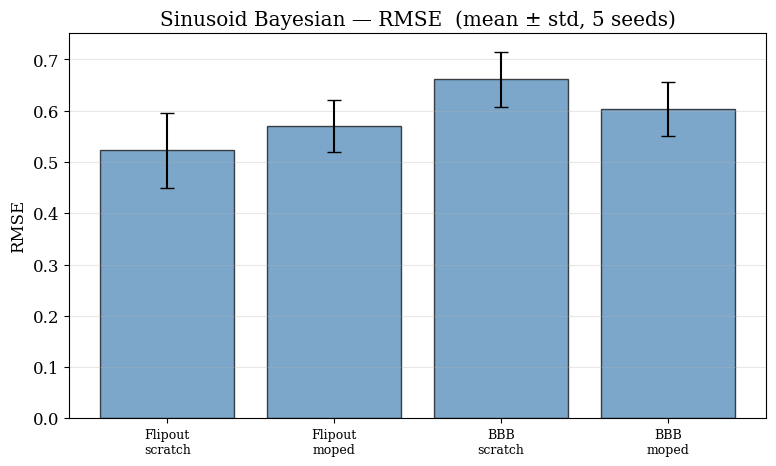

Saved: 5seed_sinusoid_bayesian_rmse_bar.png


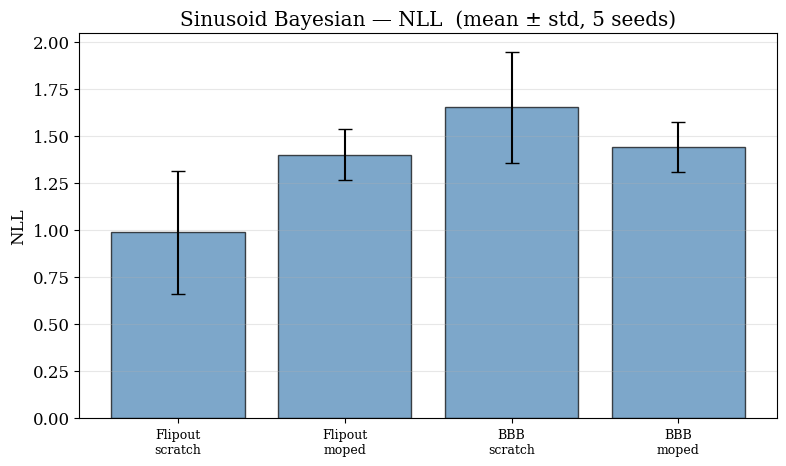

Saved: 5seed_sinusoid_bayesian_nll_bar.png


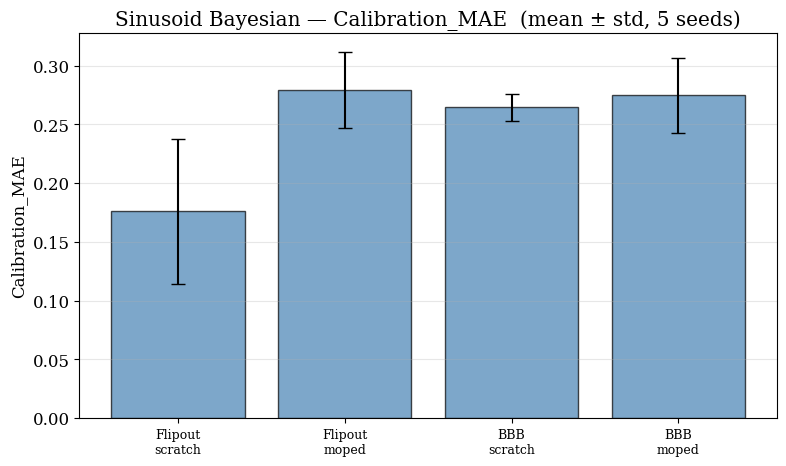

Saved: 5seed_sinusoid_bayesian_calibration_mae_bar.png


In [5]:
plot_metrics = ["RMSE", "NLL", "Calibration_MAE"]
titles = [s["plot_title"] for s in variant_specs]
n = len(titles)
x = np.arange(n)

for mk in plot_metrics:
    means = [agg[s["variant_name"]][f"{mk}_mean"] for s in variant_specs]
    stds  = [agg[s["variant_name"]][f"{mk}_std"]  for s in variant_specs]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x, means, yerr=stds, capsize=5, color="steelblue", alpha=0.7, edgecolor="k")
    ax.set_xticks(x)
    ax.set_xticklabels([t.replace(" / ", "\n") for t in titles], fontsize=9)
    ax.set_ylabel(mk)
    ax.set_title(f"Sinusoid Bayesian — {mk}  (mean ± std, {len(SEEDS)} seeds)")
    ax.grid(True, alpha=0.3, axis="y")
    fname = f"5seed_sinusoid_bayesian_{mk.lower()}_bar.png"
    fig.savefig(os.path.join(FIGURES_DIR, fname), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


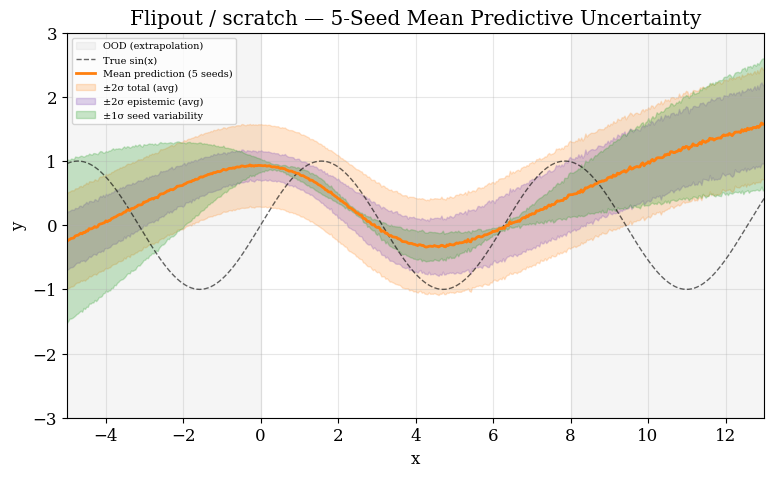

  Saved: 5seed_sinusoid_flipout_scratch_prediction.png


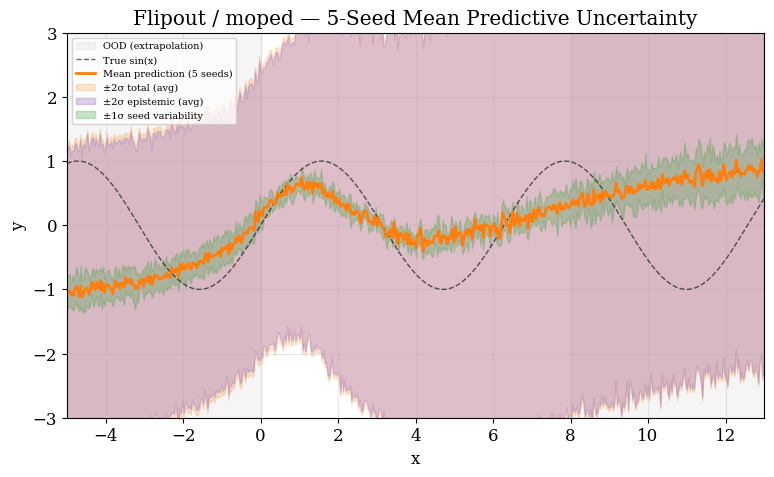

  Saved: 5seed_sinusoid_flipout_moped_prediction.png


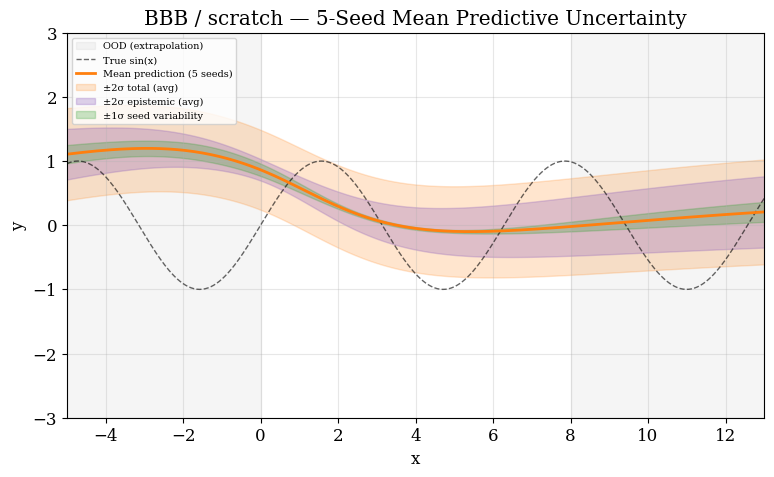

  Saved: 5seed_sinusoid_bbb_scratch_prediction.png


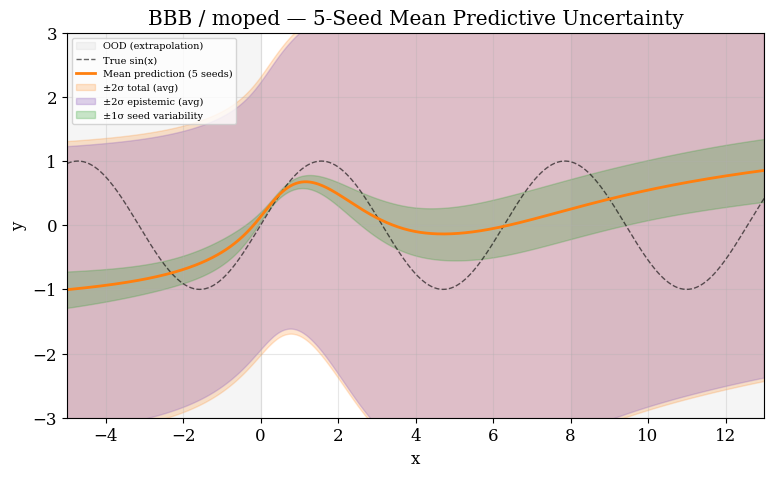

  Saved: 5seed_sinusoid_bbb_moped_prediction.png

Done: 4 prediction figures


In [6]:
for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]

    all_mus  = np.stack([all_seed_preds[s][vname][0] for s in SEEDS])
    all_epis = np.stack([all_seed_preds[s][vname][1] for s in SEEDS])

    mean_mu  = all_mus.mean(axis=0)
    std_mu   = all_mus.std(axis=0)
    mean_epi = all_epis.mean(axis=0)
    mean_total = np.sqrt(mean_epi**2 + sigma_noise**2)

    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.08)
    ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.08, label="OOD (extrapolation)")
    ax.plot(x_grid, np.sin(x_grid), "k--", lw=1, alpha=0.6, label="True sin(x)")
    ax.plot(x_grid, mean_mu, color="tab:orange", lw=2, label="Mean prediction (5 seeds)")
    ax.fill_between(x_grid, mean_mu-2*mean_total, mean_mu+2*mean_total,
                    color="tab:orange", alpha=0.20, label="±2σ total (avg)")
    ax.fill_between(x_grid, mean_mu-2*mean_epi, mean_mu+2*mean_epi,
                    color="tab:purple", alpha=0.30, label="±2σ epistemic (avg)")
    ax.fill_between(x_grid, mean_mu-std_mu, mean_mu+std_mu,
                    color="tab:green", alpha=0.25, label="±1σ seed variability")
    ax.set_xlim(-5, 13); ax.set_ylim(-3, 3)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(f"{title} — 5-Seed Mean Predictive Uncertainty")
    ax.legend(loc="upper left", fontsize=7); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"5seed_sinusoid_{vname}_prediction.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: 5seed_sinusoid_{vname}_prediction.png")
print(f"\nDone: {len(variant_specs)} prediction figures")


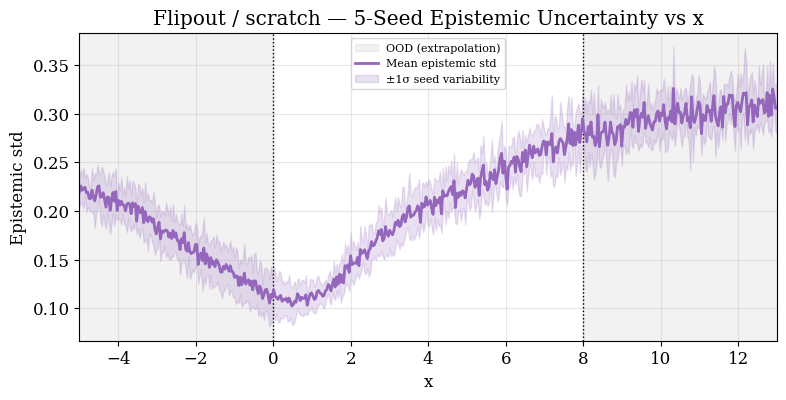

  Saved: 5seed_sinusoid_flipout_scratch_ood_epistemic.png


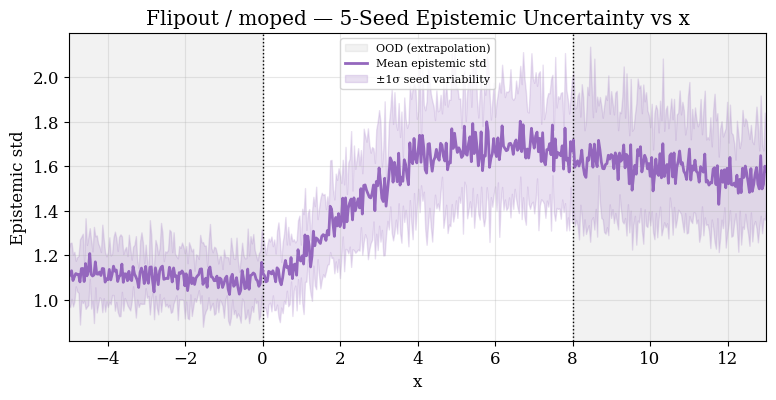

  Saved: 5seed_sinusoid_flipout_moped_ood_epistemic.png


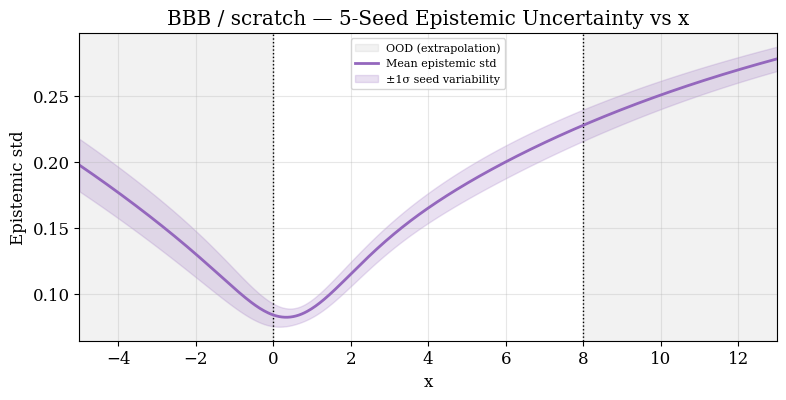

  Saved: 5seed_sinusoid_bbb_scratch_ood_epistemic.png


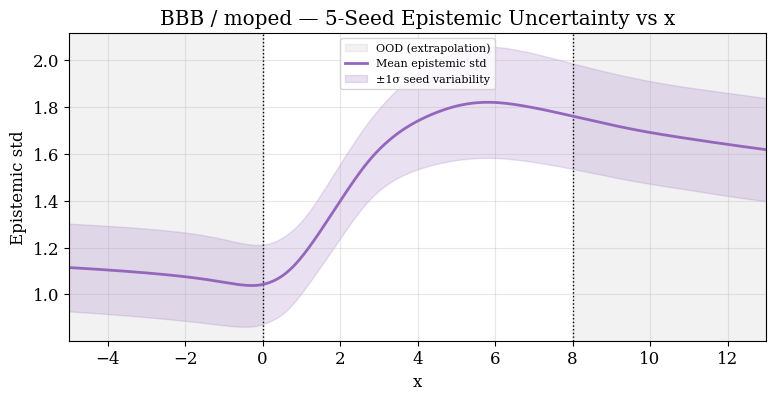

  Saved: 5seed_sinusoid_bbb_moped_ood_epistemic.png

Done: 4 OOD epistemic figures


In [7]:
for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]

    all_epis = np.stack([all_seed_preds[s][vname][1] for s in SEEDS])
    mean_epi = all_epis.mean(axis=0)
    std_epi  = all_epis.std(axis=0)

    fig, ax = plt.subplots(1, 1, figsize=(9, 4))
    ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.10, label="OOD (extrapolation)")
    ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.10)
    ax.axvline(TRAIN_LO, color="k", ls=":", lw=1)
    ax.axvline(TRAIN_HI, color="k", ls=":", lw=1)
    ax.plot(x_grid, mean_epi, color="tab:purple", lw=2, label="Mean epistemic std")
    ax.fill_between(x_grid, mean_epi-std_epi, mean_epi+std_epi,
                    color="tab:purple", alpha=0.20, label="±1σ seed variability")
    ax.set_xlim(-5, 13)
    ax.set_xlabel("x"); ax.set_ylabel("Epistemic std")
    ax.set_title(f"{title} — 5-Seed Epistemic Uncertainty vs x")
    ax.legend(loc="upper center", fontsize=8); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"5seed_sinusoid_{vname}_ood_epistemic.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: 5seed_sinusoid_{vname}_ood_epistemic.png")
print(f"\nDone: {len(variant_specs)} OOD epistemic figures")


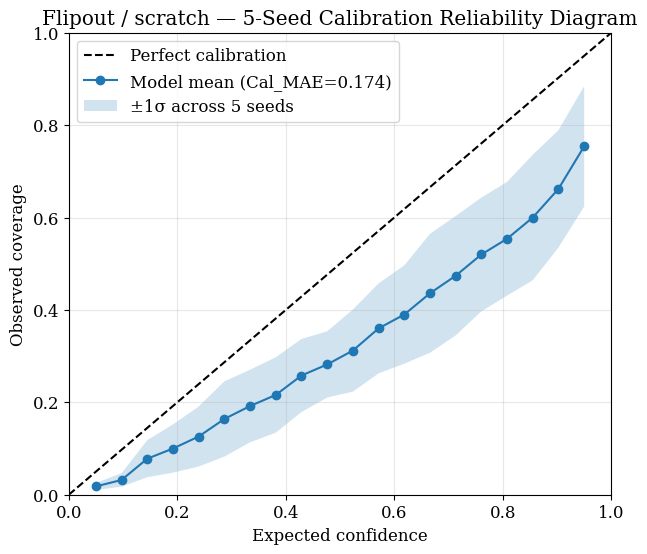

  Saved: 5seed_sinusoid_flipout_scratch_calibration.png


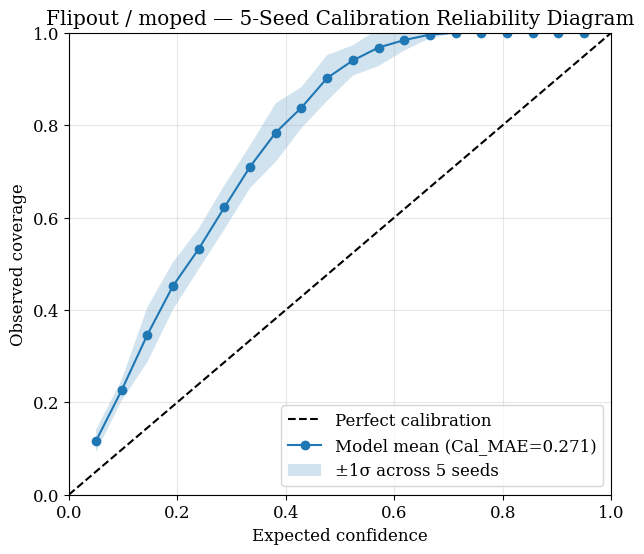

  Saved: 5seed_sinusoid_flipout_moped_calibration.png


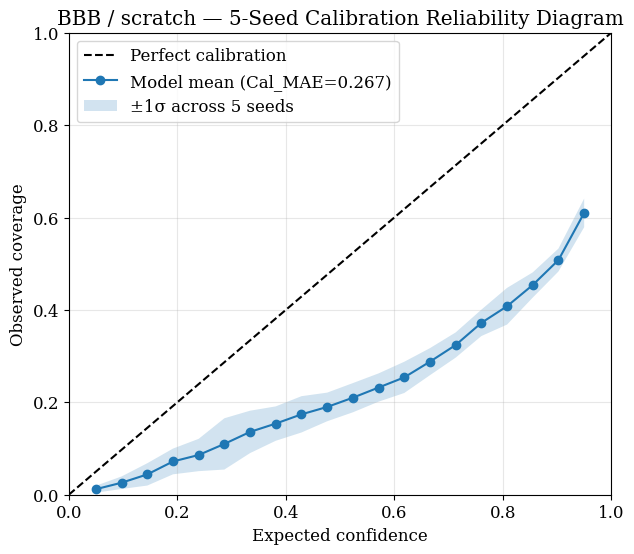

  Saved: 5seed_sinusoid_bbb_scratch_calibration.png


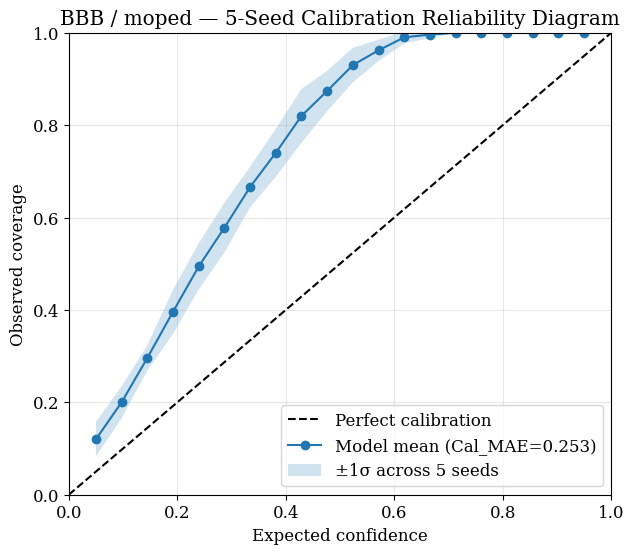

  Saved: 5seed_sinusoid_bbb_moped_calibration.png

Done: 4 calibration figures


In [8]:
# Per-variant calibration curves: mean ± std across seeds
conf_levels = np.linspace(0.05, 0.95, 20)
seed_calibration = {seed: {} for seed in SEEDS}

for seed in SEEDS:
    seed_everything(seed + 2)
    X_test_id_s = (torch.rand(100) * 8).unsqueeze(-1)
    y_test_id_s = (torch.sin(X_test_id_s) + sigma_noise * torch.randn_like(X_test_id_s)).flatten().numpy()

    for spec in variant_specs:
        vname = spec["variant_name"]
        net = all_seed_nets.get(seed, {}).get(vname)
        if net is None:
            print(f"  Warning: {vname} seed {seed} not in memory"); continue
        mu_id, epi_id = bnn_predict(net, X_test_id_s)
        total_id = np.sqrt(epi_id**2 + sigma_noise**2)
        resid = y_test_id_s - mu_id
        z_abs = np.abs(resid / np.clip(total_id, 1e-12, None))
        observed = np.array([float(np.mean(z_abs <= _norm.ppf((1+c)/2))) for c in conf_levels])
        seed_calibration[seed][vname] = observed

for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]
    obs_matrix = np.stack([seed_calibration[s][vname] for s in SEEDS if vname in seed_calibration[s]])
    mean_obs = obs_matrix.mean(axis=0)
    std_obs  = obs_matrix.std(axis=0)
    cal_mae  = float(np.mean(np.abs(mean_obs - conf_levels)))

    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(conf_levels, mean_obs, "o-", label=f"Model mean (Cal_MAE={cal_mae:.3f})")
    ax.fill_between(conf_levels, mean_obs - std_obs, mean_obs + std_obs,
                    alpha=0.2, label=f"±1σ across {len(SEEDS)} seeds")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Expected confidence"); ax.set_ylabel("Observed coverage")
    ax.set_title(f"{title} — 5-Seed Calibration Reliability Diagram")
    ax.legend(); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"5seed_sinusoid_{vname}_calibration.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: 5seed_sinusoid_{vname}_calibration.png")
print(f"\nDone: {len(variant_specs)} calibration figures")